Updated version of code 


Goals 
--> figure out why scattering produces back scattering with g = 0.9 
--> get visuals 
--> validation of current model and comparision to lit 

In [75]:
z_history = []
tissues = {
    "scalp": {"thickness": 0.51, "mu_a": 0.18, "mu_s":190, "g": 0.9, "n": 1.37}, 
    "skull":  {  "thickness": 0.52, "mu_a": 0.16, "mu_s":160, "g": 0.9, "n": 1.43}, 
    "csf":    {"thickness": 0.42, "mu_a": 0.04, "mu_s":24, "g": 0.9, "n": 1.33}, 
    "gray": {  "thickness": 0.30, "mu_a": 0.36, "mu_s":220, "g": 0.9, "n": 1.37}, 
    "white":  { "thickness": 5.0, "mu_a": 0.14, "mu_s":910, "g": 0.9, "n": 1.37}, 
    "gbm":    { "mu_a": 1.1, "mu_s":400, "g": 0.9, "n": 1.38}, 
             }
             

# checking how many photons make it to which layer 
layer_counts = {
    "scalp": 0, 
    "skull": 0, 
    "csf": 0,
    "gray": 0, 
    "white": 0,
    "gbm": 0 
}



def getTissue(d): 
    if d < 0:
        return ("out of bounds") 
    elif  d < 0.51:
        return ("scalp") 
    elif  d < 1.03:
        return ("skull") 
    elif  d < 1.45:
        return ("csf")
    elif d < 1.75:
        return ("gray") 
    elif d < 6.75:
        return("white") 
    else:
        return("out of bounds")


def simulating_one_photon(with_tumour):
    energy_list = []
    depth_list = [] 
    max_depth = []
    x_list = []
    max_steps = 10000

    weight_min = 0.001
    visited_layers = set() # keeps track of what layers the photon has encountered 



    position = np.array([0.0, 0.0, 0.0])

    direction = np.array([0.0, 0.0, 1.0]) 

    weight = 1.0 

    


    for step in range(max_steps):

        if weight < weight_min: # checks if weight threshold has been reached 
            break;

     
        

        if with_tumour: # checks if photon is in tumour 
            if tumour_center[0] - tumour_radius <= position[0] <= tumour_center[0] + tumour_radius and  tumour_center[1] - tumour_radius <= position[1] <= tumour_center[1] + tumour_radius and tumour_center[2] - tumour_radius <= position[2] <= tumour_center[2] + tumour_radius:
                tissue = "gbm"
              
            else:
                tissue = getTissue(position[2])
                if tissue == "out of bounds":
                    break;
            
        else:
            tissue = getTissue(position[2]) 
            if tissue == "out of bounds":
                break;
        if tissue in layer_counts and tissue not in visited_layers:
            layer_counts[tissue] += 1
            visited_layers.add(tissue) 

        mu_a  = tissues[tissue]["mu_a"]

        mu_s  = tissues[tissue]["mu_s"]

        mu_t  = mu_a + mu_s 

        xi = np.random.random() 

        step_s = -np.log(xi)/ mu_t  # calculating step size, s 

        position = position + direction * step_s  # updating position

        delta_W = weight * (mu_a/mu_t) # weight deposited 

        weight = weight - delta_W  # new weight 

        energy_list.append(delta_W) 

        depth_list.append(position[2])

        x_list.append(position[0])

        g = tissues[tissue]["g"]



        direction = scatter(direction, g) 





     

        


    return depth_list, energy_list, x_list 

# scattering using g 
def scatter(direction, g):
    xi = np.random.random() 
# special case scattering 
    if g == 0:
        cos_theta = 1-2*(xi)
    else:
        cos_theta = (1/(2*g)) * ((1 + (g**2)) - ((1-(g**2))/(1-g+2*g*xi))**2)

    theta = np.arccos(cos_theta) 

    phi = 2 * np.pi * np.random.random() 
# special case scattering 
    if direction[2] == 1:
        x_dir = np.sin(theta) * np.cos(phi) 
        y_dir =  np.sin(theta) * np.sin(phi) 
        z_dir = np.cos(theta) 
    elif direction[2] == -1:
        x_dir = np.sin(theta) * np.cos(phi)
        y_dir = -np.sin(theta) * np.sin(phi) 
        z_dir = -np.cos(theta) 

# using usual scattering functions to get new dir
    else:
        x_dir = (np.sin(theta) *( ( direction[0] * direction[2] * np.cos(phi)) - (direction[1] * np.sin(phi) )))/np.sqrt(1-(direction[2])**2) + direction[0] * np.cos(theta) 


        y_dir = ((np.sin(theta))* (direction[1] * direction[2] * np.cos(phi) + direction[0] * np.sin(phi)))/(np.sqrt(1-(direction[2])**2)) + direction[1] * np.cos(theta) 

        z_dir = - np.sqrt(1-(direction[2])**2) * np.sin(theta) * np.cos(phi) + direction[2] * np.cos(theta) 



    z_history.append(z_dir) 
    

    direction = np.array([x_dir, y_dir, z_dir]) 

    


   

   



    return direction





Photons reaching each layer: {'scalp': 10000, 'skull': 1376, 'csf': 757, 'gray': 697, 'white': 479, 'gbm': 1773}


Text(0.5, 1.0, 'No GBM Energy Deposition Graph, Nphotons = 1000')

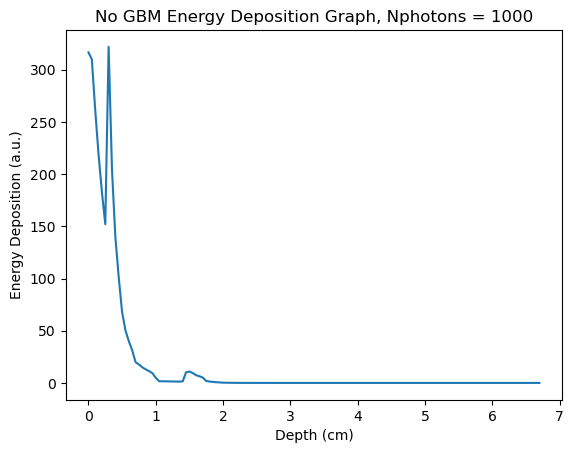

In [76]:


# simulating many photons & graphing refinements 

import numpy as np 
import matplotlib.pyplot as plt 
import random 


Nphotons = 10000

bins = np.zeros(135) 



master_depth_list = []


master_energy_list = []

master_x_list = []


tumour_center = np.array([0.0,0.0,0.5])

tumour_radius = 0.2 # in cm 



for i in range(Nphotons):
    
    depth_list, energy_list, x_list = simulating_one_photon(True) 

    master_depth_list.extend(depth_list) 

    master_energy_list.extend(energy_list)

    master_x_list.extend(x_list) 


for i in range(len(master_depth_list) ):
    assigned_idx = int(master_depth_list[i]/0.05)
    if 0 <= assigned_idx < len(bins):
        bins[assigned_idx] += master_energy_list[i] 



    




x_depth = np.arange(0,6.75, 0.05) 


print("Photons reaching each layer:", layer_counts) 
plt.plot(x_depth, bins) 
plt.xlabel("Depth (cm)")
plt.ylabel("Energy Deposition (a.u.)") 
plt.title("No GBM Energy Deposition Graph, Nphotons = 1000") 






Text(0.5, 1.0, '2D Energy Deposition Heatmap')

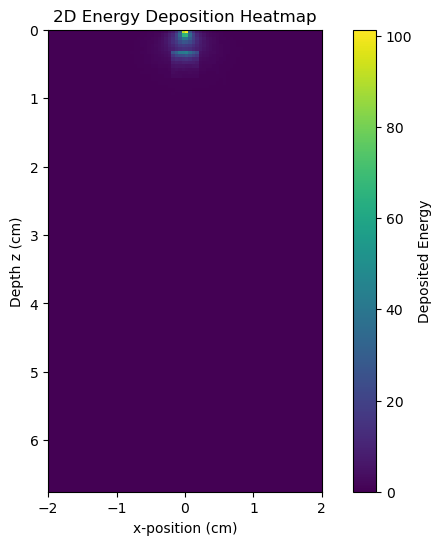

In [67]:
# 2D fluence graph 


x_min = -2
x_max = 2

# boundaries for tissue depths 
z_min = 0 
z_max = 6.75

dx = 0.05
dz = 0.05


Nx = 80
Ny = 135


heatmap = np.zeros((135, 80)) # np.zeros(row, column) 
# row index -> z pos, column index --> x pos

for i in range(len(master_x_list)):
    x = master_x_list[i] # the photons x val 
    z = master_depth_list[i] # photons depth 
    energy = master_energy_list[i] # photons deposited energy 
    x_idx = int((x-x_min)/dx) # finding column index
    z_idx = int((z-z_min)/dz) # finding row index
    if 0<= x_idx < Nx and 0<= z_idx < Ny: # checking if photon idx is within range 
         heatmap[z_idx, x_idx] += energy # adding energy to the heatmap bin 



        
# plotting 

plt.figure(figsize = (8,6))

plt.imshow( # displays data as an image 
    heatmap,
    extent = [x_min, x_max, z_max, z_min] # using the boundaries 

)

plt.colorbar(label="Deposited Energy") 
plt.xlabel("x-position (cm)")
plt.ylabel("Depth z (cm)") 
plt.title("2D Energy Deposition Heatmap") 

    
    
    
    


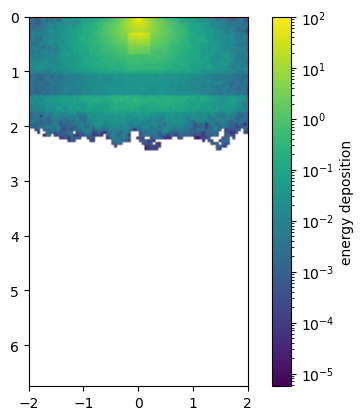

In [72]:

# TODO Log scale heatmap 

from matplotlib.colors import LogNorm 


plt.imshow(
    heatmap,
    extent = [x_min, x_max, z_max, z_min],
    cmap="viridis", # color palette 
    norm=LogNorm() # setting to log

)

plt.colorbar(label = "energy deposition") 

Text(0.5, 1.0, 'Monte Carlo Photon Trajectories')

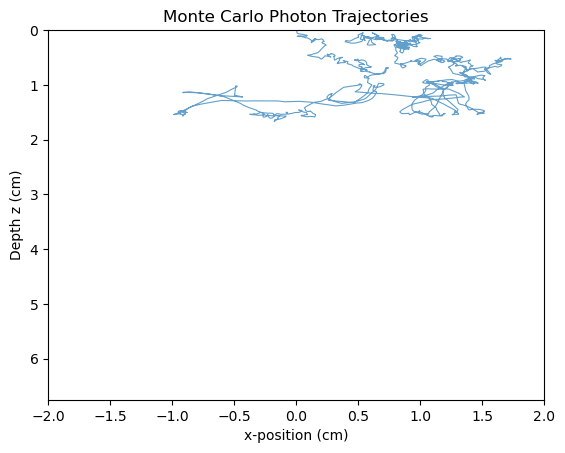

In [79]:
import matplotlib.pyplot as plt

N_trajectory_photons = 1
trajectories = []

for i in range(N_trajectory_photons):
    depth_list, energy_list, x_list = simulating_one_photon(True)

 


    trajectories.append((x_list, depth_list))



for traj_x, traj_z in trajectories: # plotting each trajectory 
    plt.plot(traj_x, traj_z, linewidth=0.8, alpha=0.7)



plt.xlim(-2, 2)
plt.ylim(6.75, 0)

plt.xlabel("x-position (cm)")
plt.ylabel("Depth z (cm)")
plt.title("Monte Carlo Photon Trajectories")
2
